Milestone 3: Neural Network Designs

This is for creating our baseline model without any tuning or many layers.

In [1]:
import tensorflow as tf
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
from pathlib import Path
from time import strftime
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)

def get_run_logdir(root_logdir='my_logs'):
    return Path(root_logdir)/strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))


def create_baseline(meta):
    X_shape_ = meta["X_shape_"]
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(300, activation="relu", input_shape=(X_shape_[1],)),
        tf.keras.layers.Dense(300, activation="relu"),
        tf.keras.layers.Dense(4, activation="softmax")
    ])
    model.compile(optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])
    return model


In [2]:
clf = KerasClassifier(model=create_baseline, epochs=50, batch_size=32, verbose=1)

This results array will hold all of our results for each model to see which one performed the best for different metrics at the end.

In [3]:
results = []

Here we are just loading and splitting the data as needed.

In [4]:
import numpy as np
from sklearn.svm import LinearSVC
data = np.load('octmnist.npz')
print("Keys in octmnist.npz: ", data.files)

for k in data.files:
    arr = data[k]
    print(f"{k:>12}: shape = {arr.shape}")

Keys in octmnist.npz:  ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
train_images: shape = (97477, 28, 28)
  val_images: shape = (10832, 28, 28)
 test_images: shape = (1000, 28, 28)
train_labels: shape = (97477, 1)
  val_labels: shape = (10832, 1)
 test_labels: shape = (1000, 1)


In [5]:
train_images = data["train_images"]
train_labels = data["train_labels"].ravel()

val_images = data["val_images"]
val_labels = data["val_labels"].ravel()

test_images = data["test_images"]
test_labels = data["test_labels"].ravel()

This is our first model pipeline where we flatten, scale and use the base neural network we created.

In [6]:
from utils import flattener
from sklearn.preprocessing import MinMaxScaler

pipe_baseline = Pipeline([
    ("Flatten", flattener),
    ("Scale", MinMaxScaler()),
    ("model", clf)
])

In [7]:
from utils import train_eval_model
from utils import stratified_subset

x_tr, y_tr = stratified_subset(train_images, train_labels, 22000) #based on assignement instructions
x_va, y_va = stratified_subset(val_images, val_labels, 2000)

results.append(train_eval_model("Baseline NN", pipe_baseline, x_tr, y_tr, x_va, y_va, callbacks=[early_stopping_cb, tensorboard_cb]))

c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5779 - loss: 1.0388
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6393 - loss: 0.9340
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6665 - loss: 0.8766
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6903 - loss: 0.8253
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7088 - loss: 0.7802
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7321 - loss: 0.7325
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7384 - loss: 0.7083
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7502 - loss: 0.6820
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7615 - loss: 0.6565
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7713 - loss: 0.6325
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7711 - loss: 0.6220
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

To absolutely no ones suprise even the completely untuned most baseline neural network possible sort of destroyed all other models.

This is our second model pipeline where we use the base neural network we created along with median and averaging. 

In [8]:
from utils import median, avg_2x2_pool, flatten_data
from sklearn.preprocessing import FunctionTransformer

avg_median_nn = Pipeline([
    ("median", FunctionTransformer(median)),
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("flat", FunctionTransformer(flatten_data)),
    ("scale", MinMaxScaler()),
    ("model", clf)
])

In [9]:
results.append(train_eval_model("Avg+median filtering w/ Baseline NN", avg_median_nn, x_tr, y_tr, x_va, y_va, callbacks=[early_stopping_cb, tensorboard_cb]))

Epoch 1/50


c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5808 - loss: 1.0411
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6343 - loss: 0.9473
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6553 - loss: 0.9060
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6720 - loss: 0.8727
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6787 - loss: 0.8458
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6907 - loss: 0.8250
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6960 - loss: 0.8092
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7067 - loss: 0.7925
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7124 - loss: 0.7756
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7208 - loss: 0.7579
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7219 - loss: 0.7508
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy

Performed Worse than on just the raw training data.

This is our third model pipeline where we use the base neural network we created along with only averaging for preprocessing. 

In [10]:
avg_nn = Pipeline([
    ("avg14", FunctionTransformer(avg_2x2_pool)),
    ("flat", FunctionTransformer(flatten_data)),
    ("scale", MinMaxScaler()),
    ("model", clf)
])

In [11]:
results.append(train_eval_model("Avg filtering w/ Baseline NN", avg_nn, x_tr, y_tr, x_va, y_va, callbacks=[early_stopping_cb, tensorboard_cb]))

Epoch 1/50


c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5787 - loss: 1.0376
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6395 - loss: 0.9270
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6719 - loss: 0.8669
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6868 - loss: 0.8319
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7007 - loss: 0.7999
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7111 - loss: 0.7757
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7214 - loss: 0.7518
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7282 - loss: 0.7305
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7347 - loss: 0.7163
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7449 - loss: 0.6942
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7471 - loss: 0.6815
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy

Once again overall a worse performance. Preprocessing appears to be a possible detriment for this.

This is our fourth pipeline where we use the base neural network we created along with only median filtering for preprocessing.

In [12]:
median_nn = Pipeline([
    ("median", FunctionTransformer(median)),
    ("Flatten", flattener),
    ("Scale", MinMaxScaler()),
    ("model", clf)
])

In [13]:
results.append(train_eval_model("Median filtering w/ Baseline NN", median_nn, x_tr, y_tr, x_va, y_va, callbacks=[early_stopping_cb, tensorboard_cb]))

Epoch 1/50


c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5727 - loss: 1.0502
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6315 - loss: 0.9559
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6486 - loss: 0.9137
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6657 - loss: 0.8808
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6812 - loss: 0.8510
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6862 - loss: 0.8306
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6964 - loss: 0.8102
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7036 - loss: 0.7937
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7119 - loss: 0.7749
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7164 - loss: 0.7613
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7205 - loss: 0.7489
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy

Now we are exploring using CNN's for this. We thought that CNN's work well for images and this problem is in a simplified manner, an image classification problem.

This first CNN is a CNN only model with no preprocessing.

In [14]:
def prep_for_cnn(X):
    X = X.astype("float32") / 255.0
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
    return X

In [15]:
#we first need to make sure the data is ready for a cnn (see utils helper)
x_tr_cnn = prep_for_cnn(x_tr) #train
x_va_cnn = prep_for_cnn(x_va) #validation

In [16]:
from tensorflow import keras

def make_cnn():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),
        keras.layers.Conv2D(64, kernel_size=3, activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2), #2x2
        keras.layers.Conv2D(32, kernel_size=3, activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Flatten(),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [17]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score

def train_eval_cnn(name, model, x_tr, y_tr, x_va, y_va):
    t1 = time.time()

    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_va, y_va),
        epochs=20,
        batch_size=32,
        verbose=1
    )

    t2 = time.time()

    probs = model.predict(x_va)
    pred = probs.argmax(axis=1)

    acc = accuracy_score(y_va, pred)
    prec = precision_score(y_va, pred, average="weighted")
    rec = recall_score(y_va, pred, average="weighted")
    train_time = t2-t1

    print(f"Model: {name}")
    print(f"Training Time: {t2-t1}")
    print(f"acc: {acc}")
    print(f"prec: {prec}")
    print(f"recall: {rec}")

    return history, {
        "Model": name,
        "Train time (s)": round(train_time, 3),
        "Val Acc": round(acc, 4),
        "Val Precision": round(prec, 4),
        "Val Recall": round(rec, 4)
    }

In [18]:
cnn_model = make_cnn()
cnn_history, cnn_result = train_eval_cnn(
    "Simple CNN",
    cnn_model, #using the model we created
    x_tr_cnn, y_tr,
    x_va_cnn, y_va
)

results.append(cnn_result)

Epoch 1/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6334 - loss: 0.9458 - val_accuracy: 0.7240 - val_loss: 0.7470
Epoch 2/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7527 - loss: 0.6899 - val_accuracy: 0.7770 - val_loss: 0.6077
Epoch 3/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7841 - loss: 0.6055 - val_accuracy: 0.7990 - val_loss: 0.5489
Epoch 4/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8015 - loss: 0.5588 - val_accuracy: 0.8105 - val_loss: 0.5400
Epoch 5/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8128 - loss: 0.5269 - val_accuracy: 0.8115 - val_loss: 0.5276
Epoch 6/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8231 - loss: 0.4990 - val_accuracy: 0.8195 - val_loss: 0.4929
Epoch 7/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8303 - loss: 0.4774 - val_accuracy: 0.8285 - val_loss: 0.4761
Epoch 8/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8339 - loss: 0.4659 - val_accuracy: 0.

This next CNN model will use the same CNN structure but this time also using median too.

In [19]:
def prep_median_for_cnn(X):
    X_med = median(X)
    X_med = X_med.astype("float32") / 255.0
    X_med = X_med.reshape(X_med.shape[0], X_med.shape[1], X_med.shape[2], 1)
    return X_med

In [20]:
x_tr_cnn_med = prep_median_for_cnn(x_tr)
x_va_cnn_med = prep_median_for_cnn(x_va)

In [21]:
cnn_med_model = make_cnn()
cnn_med_history, cnn_med_result = train_eval_cnn(
    "Median CNN",
    cnn_med_model,
    x_tr_cnn_med, y_tr,
    x_va_cnn_med, y_va
)

results.append(cnn_med_result)

Epoch 1/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5935 - loss: 1.0222 - val_accuracy: 0.6900 - val_loss: 0.8448
Epoch 2/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7050 - loss: 0.8148 - val_accuracy: 0.7100 - val_loss: 0.7823
Epoch 3/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7284 - loss: 0.7564 - val_accuracy: 0.7380 - val_loss: 0.7098
Epoch 4/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7509 - loss: 0.7028 - val_accuracy: 0.7530 - val_loss: 0.6844
Epoch 5/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7641 - loss: 0.6629 - val_accuracy: 0.7580 - val_loss: 0.6568
Epoch 6/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7734 - loss: 0.6405 - val_accuracy: 0.7615 - val_loss: 0.6561
Epoch 7/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7805 - loss: 0.6098 - val_accuracy: 0.7640 - val_loss: 0.6466
Epoch 8/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7884 - loss: 0.5925 - val_accuracy: 0.

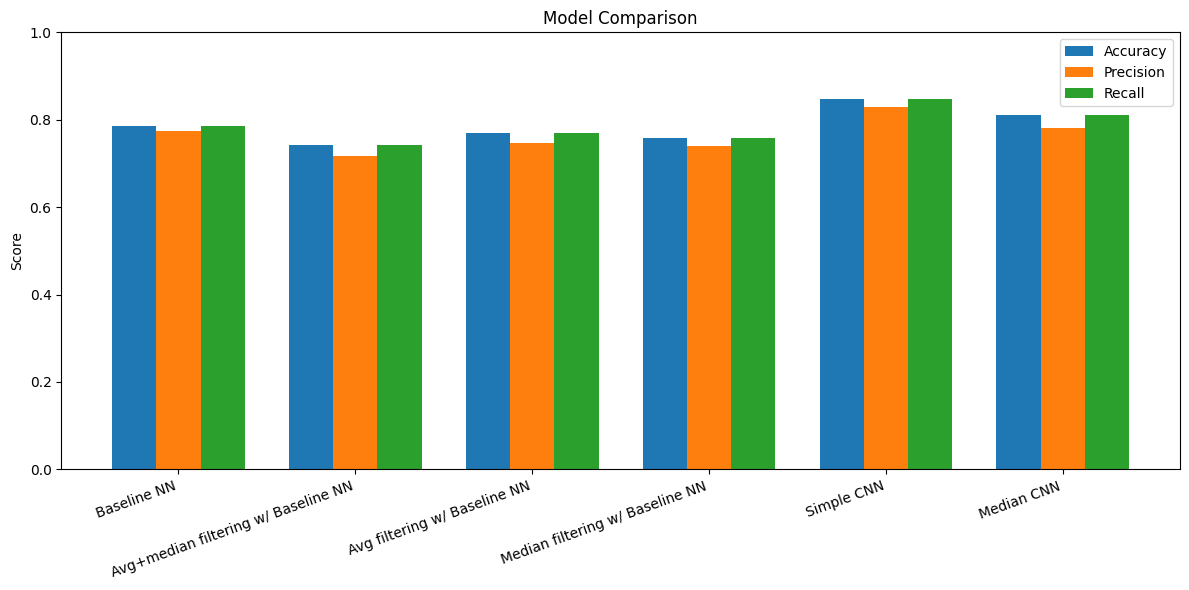

In [22]:
import matplotlib.pyplot as plt
import numpy as np

models = [r["Model"] for r in results]
accuracy = [r["Val Acc"] for r in results]
precision = [r["Val Precision"] for r in results]
recall = [r["Val Recall"] for r in results]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, accuracy, width, label="Accuracy")
ax.bar(x, precision, width, label="Precision")
ax.bar(x + width, recall, width, label="Recall")

ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

All perfrom roughly similar with a slight edge to no preprocessing at this moment.

In [ ]:
label_names = {
    0: "Normal",
    1: "Choroidal neovascularization",
    2: "Diabetic macular edema",
    3: "Drusen"
}

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)

Now lets test results on a wide and deep network. The goal of a wide and deep network is to both hopefully learn simple patterns that can be learned just from the input data. As well as complex patterns that can be learned from the deep path too.

In [ ]:
def create_wide_and_deep(meta):
    '''Creates the wide & deep network.
    deep network is designed to be same as pervious networks
    so we can guage if the width actually adds anything to the network.
    '''
    X_shape = meta["X_shape_"]
    print(X_shape)

    inputs= tf.keras.layers.Input(shape=(X_shape[1],))

    hidden_layer_1 = tf.keras.layers.Dense(300, activation='relu')(inputs)
    hidden_layer_2 = tf.keras.layers.Dense(300, activation='relu')(hidden_layer_1)

    concat_layer = tf.keras.layers.Concatenate()([inputs, hidden_layer_2])
    output_layer = tf.keras.layers.Dense(4, activation="softmax")(concat_layer)


    model = tf.keras.Model(inputs=inputs, outputs=output_layer)

    model.compile(optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])
    return model

clf_wide = KerasClassifier(model=create_wide_and_deep, epochs=50, batch_size=32, verbose=1)

pipe_baseline_wide = Pipeline([
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

In [ ]:
train_eval_model(
    name="Wide & Deep baseline model",
    model=pipe_baseline_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

Very consistent results but nothing incredible.

In [ ]:
pipe_avg_wide = Pipeline([
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

train_eval_model(
    name="Wide & Deep baseline model",
    model=pipe_avg_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)


Best Accuracy So Far, but lower precision

In [ ]:
pipe_med_avg_wide = Pipeline([
    ("med", FunctionTransformer(median)),
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

train_eval_model(
    name="Wide & Deep Median + Avg model",
    model=pipe_med_avg_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

In [ ]:
def create_wide_and_deep_subsample(meta, wide_frac=0.5, deep_frac=0.5, seed=42):
    X_shape_ = meta["X_shape_"]
    n_features = X_shape_[1]

    rng = np.random.RandomState(seed)
    wide_idx = rng.choice(n_features, size=int(n_features * wide_frac), replace=False)
    deep_idx = rng.choice(n_features, size=int(n_features * deep_frac), replace=False)

    inputs = tf.keras.layers.Input(shape=(n_features,))

    wide_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, wide_idx, axis=1))(inputs)
    deep_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, deep_idx, axis=1))(inputs)

    # Deep path
    deep = tf.keras.layers.Dense(300, activation="relu")(deep_input)
    deep = tf.keras.layers.Dense(300, activation="relu")(deep)

    # Concatenate
    concat = tf.keras.layers.Concatenate()([wide_input, deep])

    output = tf.keras.layers.Dense(4, activation="softmax")(concat)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"]
    )
    return model

clf_wide_subsample = KerasClassifier(model=create_wide_and_deep_subsample, epochs=50, batch_size=32, verbose=1)

pipe_wide_subsample_base = Pipeline([
    ("flat", flattener),
    ("scale", MinMaxScaler()),
    ("model", clf_wide_subsample)
])

train_eval_model(
    name="Wide & Deep with feature subsampling",
    model=pipe_wide_subsample_base,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

The wide and deep model performed slightly better than the baseline model. Interestingly there seems to be a percision recall trade off between averaging for this case. When averaging to reduce dimensionality the precision dropped but the recall increased. I would interpret this as the model sort of being more 'certain' or 'aggressive' in it's guessing leading to more total positive cases captured on average per class but also less overall accuracy on those guesses. Ultimately we should take both these into consideration especially when acknowledging that our models are tuned for Accuracy (Marco Recall).

Let us now look towards tuning an existing model and observe the results there. First we will explore general ideas in model architecture. Number of layers, number of neurons, learning rate, and basic optimimizer choices. This can help us get more insight into what kind of model architectures are doing well for this problem.

In [ ]:
import keras_tuner as kt

def build_tuned_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")

    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    avg = hp.Choice("avg", values=[True, False])
    pool = hp.Int("pool_size", min_value=2, max_value=4)
    activation = hp.Choice("activation", values=["relu", "leaky_relu", "elu", "selu"])
    batch_norm = hp.Choice("batch_norm", values=[True, False])
    decay_rate = hp.Float("decay_rate", min_value=0.9, max_value=0.99, step=0.01)

    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )
    else:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )

    model = tf.keras.Sequential()

    if avg:
        model.add(tf.keras.layers.Reshape((28, 28, 1))) #Added because 4d data is expected for average pooling
        model.add(tf.keras.layers.AveragePooling2D(pool_size=(pool, pool)))

    model.add(tf.keras.layers.Rescaling(scale=1.0 / 255)) #Our MinMaxScaler in tensorflow format

    model.add(tf.keras.layers.Flatten())

    dropout_rate = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)

    for i in range(n_hidden):
        n_neurons = hp.Int(f"n_neurons{i}", min_value=16, max_value=256)
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation))
        if batch_norm:
            model.add(tf.keras.layers.BatchNormalization())
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(4, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

This is a pretty deep tuning search. so lets break it down.
1. This allows us first and formost give a general idea of what model architecture is preferred (deep path vs shallow, wide layers vs small layers)
2. Control our preprocessing step through the averaging choice.
3. Have a preliminary search over activation functions & optimizers
4. Introduce batch normalization & dropout rate if it is beneficial.

In [ ]:
tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_accuracy",
    max_trials=50,
    directory="tuning_results",
    project_name="my_rnd_search",
)

tuner.search(
    x_tr, y_tr,
    epochs=50,
    validation_data=(x_va, y_va),
    callbacks=[
        early_stopping_cb,
        tensorboard_cb
    ]
)